In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse
from tqdm import trange, tqdm


# Color Palette
ColorBlue   =  ["#00B4FA","#00A3E9","#0093D9","#0082C8","#0071B7","#0061A7","#005096","#003F85","#002F75","#001E64"]
ColorRed    =  ["#FA5050","#F24747","#EA3E3E","#E33535","#DB2C2C","#D32424","#CB1B1B","#C41212","#BC0909","#B40000"]
ColorGreen  =  ["#96D250","#85C850","#75BE50","#64B450","#53AA50","#43A050","#329650","#218C50","#118250","#007850"]
ColorYellow =  ["#FAFA00","#FAE903","#FAD907","#FAC80A","#FAB70D","#FAA711","#FA9614","#FA8517","#FA751B","#FA641E"]
ColorPurple =  ["#FA82FA","#E774E8","#D465D6","#C157C5","#AE48B3","#9C3AA1","#892B8F","#761D7E","#630E6C","#50005A"]
ColorGray   =  ["#B4B4B4","#A4A4A4","#959595","#858585","#767676","#666666","#575757","#474747","#383838","#282828"]

### 参数设置

In [2]:

N = 1000
dt = 0.01 # ms
Time = 1000.0 # ms
T = int(Time/dt)
V_rest = -70.0 # Resting potential, unit: mV
V_reset = -60.0 # Reset potential, unit: mV
threshold = -50.0 # Threshold potential, unit: mV
t_ref = 2.0 # Refractory period, unit: ms
ref_length = int(t_ref/dt)
C = 500.0 # Capacitance, unit: pF
g_L = 25.0 # Leakage conductance, unit: nS
g_ampa = 2.0 # AMPA conductance, unit: nS
tau_ampa = 2.0 # unit: ms
V_E = 0.0 # unit: mV

noise_freqs = np.arange(1.5,3.05,0.05, dtype=np.float32) # kHz
spike_freqs = np.zeros(len(noise_freqs), dtype=np.float32)

rng = np.random.default_rng()

### 响应函数

In [4]:

for i in range(len(noise_freqs)):
    p_noise = noise_freqs[i] * dt
    spikes_external = rng.binomial(1, p_noise, (N, T))
    V = np.full((N, T), V_rest)
    not_refractory = np.ones((N, T))
    spikes = np.zeros((N, T))
    I_ext = np.zeros((N, T))
    I_rec = np.zeros((N, T))
    p = 0.0
    W = sparse.csr_matrix(rng.random((N, N)) < p,dtype=np.float64)
    S_ampa_ext = np.zeros((N, T))
    S_ampa_rec = np.zeros((N, T))
    for t in range(1, T):
        V[:,t] = V[:,t-1] + dt/C*(-g_L*(V[:,t-1]-V_rest)-(I_ext[:,t-1]+I_rec[:,t-1])*not_refractory[:,t-1])
        spikes[V[:,t] > threshold, t] = 1
        V[spikes[:,t] == 1,t-1] = 0
        V[spikes[:,t] == 1,t] = V_reset
        refractory_steps = np.minimum(t+ref_length, T)
        not_refractory[spikes[:,t]==1,t:refractory_steps] = 0
        S_ampa_ext[:,t] = S_ampa_ext[:,t-1]-S_ampa_ext[:,t-1]/tau_ampa*dt + spikes_external[:,t-1]
        I_ext[:, t] = g_ampa * (V[:,t] - V_E) * S_ampa_ext[:,t]
        S_ampa_rec[:, t] = S_ampa_rec[:, t-1] - S_ampa_rec[:, t-1] / tau_ampa * dt + spikes[:, t-1]
        I_rec[:, t] = g_ampa * (V[:, t] - V_E) * (W @ S_ampa_rec[:, t])
    spike_freqs[i] = np.sum(spikes, axis=1).mean(axis=0) / Time * 1000
np.save("Noise Frequencies.npy", noise_freqs)
np.save("Spike Frequencies.npy", spike_freqs)

### 理论预测

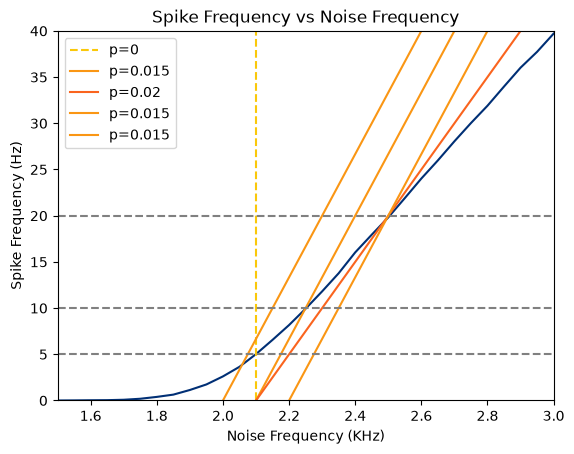

In [3]:
noise_freqs = np.load("Noise Frequencies.npy")
spike_freqs = np.load("Spike Frequencies.npy")
z = 2.1 # KHz
z_2 = 2.2
z_3 = 2.0
p_1 = 0.015
p_2 = 0.020
N = 1000
def line_1(x: float) -> float:
    return (x - z)*1000 / (p_1 * N)
def line_2(x: float) -> float:
    return (x - z)*1000 / (p_2 * N)

def line_3(x: float) -> float:
    return (x - z_2)*1000 / (p_1 * N)
def line_4(x: float) -> float:
    return (x - z_3)*1000 / (p_1 * N)
plt.plot(noise_freqs, spike_freqs,color=ColorBlue[8])
plt.vlines(z, 0, 50, color=ColorYellow[3], linestyles="dashed", label="p=0")
plt.plot(noise_freqs, line_1(noise_freqs),color=ColorYellow[6], label="p=0.015")
plt.plot(noise_freqs, line_2(noise_freqs),color=ColorYellow[9], label="p=0.02")
plt.plot(noise_freqs, line_3(noise_freqs),color=ColorYellow[6], label="p=0.015")
plt.plot(noise_freqs, line_4(noise_freqs),color=ColorYellow[6], label="p=0.015")
plt.xlim([1.5, 3.0])
plt.ylim([0, 40])
plt.xlabel("Noise Frequency (KHz)")
plt.ylabel("Spike Frequency (Hz)")
plt.title("Spike Frequency vs Noise Frequency")
plt.hlines(5, 1.5, 3.0, colors="gray", linestyles="dashed")
plt.hlines(10, 1.5, 3.0, colors="gray", linestyles="dashed")
plt.hlines(20, 1.5, 3.0, colors="gray", linestyles="dashed")
plt.legend()

### 实验验证

Rep 0 start


100%|██████████| 99999/99999 [00:06<00:00, 16663.11it/s]


Calculating spike frequency


190it [00:00, 896.74it/s]


Rep 1 start


...

Rep 9 start


100%|██████████| 99999/99999 [00:05<00:00, 16693.60it/s]


Calculating spike frequency


190it [00:00, 855.96it/s]


Text(0.5, 1.0, 'Spike Frequency vs Time, freq=2.1KHz, p=0.02')

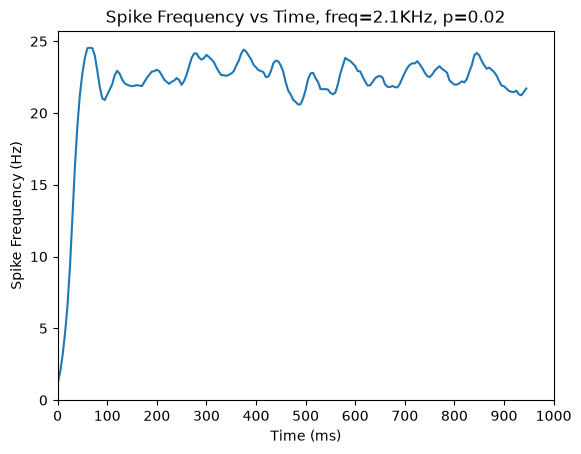

In [29]:
Rep = 10
p_noise = 2.1 * dt
p = 0.02

window_size = int(50 / dt)
shift_size = int(5 / dt)
x = np.arange(0, T - window_size, shift_size)
spike_freqs = np.zeros((Rep,len(x)))


for rep in range(Rep):
    spikes_external = rng.binomial(1, p_noise, (N, T))
    V = np.full((N, T), V_rest)
    not_refractory = np.ones((N, T))
    spikes = np.zeros((N, T))
    I_ext = np.zeros((N, T))
    I_rec = np.zeros((N, T))
    W = sparse.csr_matrix(rng.random((N, N)) < p,dtype=np.float32)
    S_ampa_ext = np.zeros((N, T))
    S_ampa_rec = np.zeros((N, T))
    print(f"Rep {rep} start")
    for t in trange(1, T):
        V[:,t] = V[:,t-1] + dt/C*(-g_L*(V[:,t-1]-V_rest)-(I_ext[:,t-1]+I_rec[:,t-1])*not_refractory[:,t-1])
        spikes[V[:,t] > threshold, t] = 1
        V[spikes[:,t] == 1,t-1] = 0
        V[spikes[:,t] == 1,t] = V_reset
        refractory_steps = np.minimum(t+ref_length, T)
        not_refractory[spikes[:,t]==1,t:refractory_steps] = 0
        S_ampa_ext[:,t] = S_ampa_ext[:,t-1]-S_ampa_ext[:,t-1]/tau_ampa*dt + spikes_external[:,t-1]
        I_ext[:, t] = g_ampa * (V[:,t] - V_E) * S_ampa_ext[:,t]
        S_ampa_rec[:, t] = S_ampa_rec[:, t-1] - S_ampa_rec[:, t-1] / tau_ampa * dt + spikes[:, t-1]
        I_rec[:, t] = g_ampa * (V[:, t] - V_E) * (W @ S_ampa_rec[:, t])
    print("Calculating spike frequency")   
    for i, t in tqdm(enumerate(x)):
        spike_freqs[rep,i] = np.sum(spikes[:, t:t+window_size], axis=1).mean(axis=0) / 50 * 1000

plt.plot(x, np.mean(spike_freqs,axis=0))
plt.xlim([0,T])
plt.xticks(np.arange(0, T+1, int(T/10)),np.arange(0,1001,100))
plt.xlabel("Time (ms)")
plt.ylabel("Spike Frequency (Hz)")
plt.title(f"Spike Frequency vs Time, freq={p_noise/dt}KHz, p={p}")



### 2.1KHz, p=0.02

![](./2_1_khz_0_02.png)

### 2.2KHz, p=0.015

![](./2_2_khz_0_015.png)

为什么第二个发放率更低？

连接更少，recurrent更少

其实高于预测值的原因是因为这些spike其实是有相关性的

Text(0, 0.5, 'Spike Frequency (Hz)')

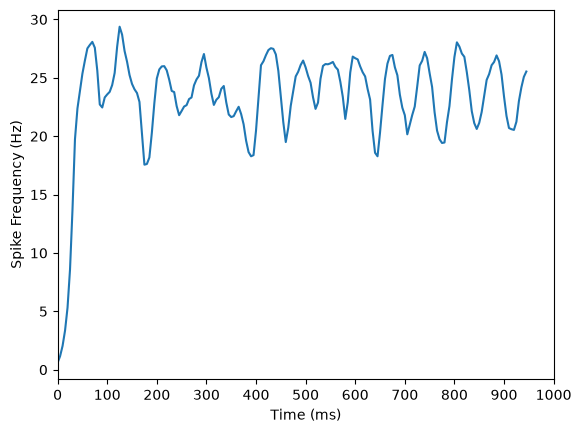

In [8]:
# plt.plot(x, spike_freqs[0])
# plt.plot(x, spike_freqs[1])
# plt.plot(x, spike_freqs[2])
plt.plot(x, spike_freqs[-1])
plt.xlim([0,T])
plt.xticks(np.arange(0, T+1, int(T/10)),np.arange(0,1001,100))
plt.xlabel("Time (ms)")
plt.ylabel("Spike Frequency (Hz)")

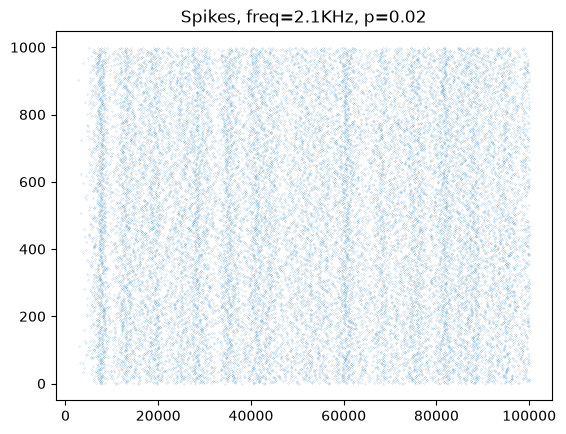

In [31]:
plt.title(f"Spikes, freq={p_noise/dt}KHz, p={p}")
plt.scatter(np.where(spikes==1)[1], np.where(spikes==1)[0], s=0.01)


### 扰动实验

100%|██████████| 99999/99999 [00:05<00:00, 17536.37it/s]


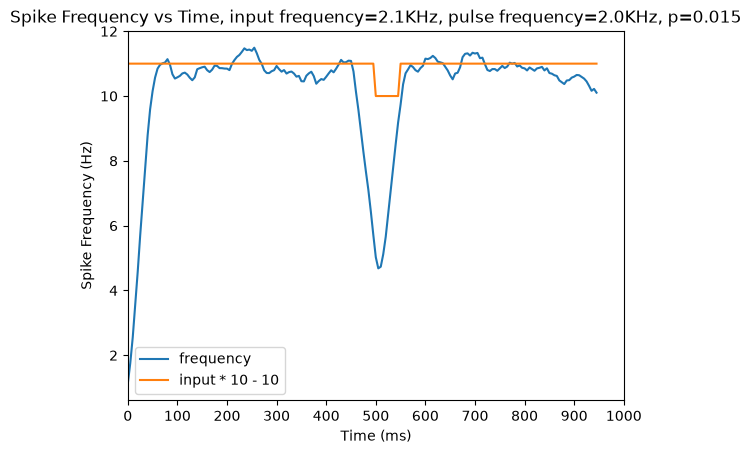

In [27]:
Rep = 10
# p_noise = 2.1 * dt
p = 0.015
base_freq = 2.1
pulse_freq = 2.0
pulse_start = int(500 / dt)
pulse_end = int(550 / dt)
freq = np.full(T, base_freq)
freq[pulse_start:pulse_end] = pulse_freq
p_noise = freq * dt


window_size = int(50 / dt)
shift_size = int(5 / dt)
x = np.arange(0, T - window_size, shift_size)
spike_freqs = np.zeros((Rep,len(x)))
freq_plot = np.zeros(len(x))

for rep in range(Rep):
    spikes_external = rng.binomial(1, p_noise, (N, T))
    V = np.full((N, T), V_rest)
    not_refractory = np.ones((N, T))
    spikes = np.zeros((N, T))
    I_ext = np.zeros((N, T))
    I_rec = np.zeros((N, T))
    W = sparse.csr_matrix(rng.random((N, N)) < p,dtype=np.float64)
    S_ampa_ext = np.zeros((N, T))
    S_ampa_rec = np.zeros((N, T))
    for t in trange(1, T):
        V[:,t] = V[:,t-1] + dt/C*(-g_L*(V[:,t-1]-V_rest)-(I_ext[:,t-1]+I_rec[:,t-1])*not_refractory[:,t-1])
        spikes[V[:,t] > threshold, t] = 1
        V[spikes[:,t] == 1,t-1] = 0
        V[spikes[:,t] == 1,t] = V_reset
        refractory_steps = np.minimum(t+ref_length, T)
        not_refractory[spikes[:,t]==1,t:refractory_steps] = 0
        S_ampa_ext[:,t] = S_ampa_ext[:,t-1]-S_ampa_ext[:,t-1]/tau_ampa*dt + spikes_external[:,t-1]
        I_ext[:, t] = g_ampa * (V[:,t] - V_E) * S_ampa_ext[:,t]
        S_ampa_rec[:, t] = S_ampa_rec[:, t-1] - S_ampa_rec[:, t-1] / tau_ampa * dt + spikes[:, t-1]
        I_rec[:, t] = g_ampa * (V[:, t] - V_E) * (W @ S_ampa_rec[:, t])
    for i, t in enumerate(x):
        spike_freqs[rep,i] = np.sum(spikes[:, t:t+window_size], axis=1).mean(axis=0) / 50 * 1000
        freq_plot[i] = freq[t]
plt.title(f"Spike Frequency vs Time, input frequency={base_freq}KHz, pulse frequency={pulse_freq}KHz, p={p}")
plt.plot(x, np.mean(spike_freqs,axis=0), label="frequency")
plt.plot(x, freq_plot * 10 - 10, label="input * 10 - 10")
plt.xlim([0,T])
plt.xticks(np.arange(0, T+1, int(T/10)),np.arange(0,1001,100))
plt.xlabel("Time (ms)")
plt.ylabel("Spike Frequency (Hz)")
plt.legend()

写讲义

## 抑制性神经元